# RecetaExpress

**POC de Prompt Engineering para recomendación de recetas a partir de ingredientes disponibles**

Autor: FrancoFEFA · Repositorio: https://github.com/FrancoFEFA/RecetaExpress


## 2. Descripción del proyecto

RecetaExpress es una prueba de concepto que, a partir de los ingredientes que una persona tiene en casa, sugiere recetas realistas clasificadas en tres grupos:

1. **Recetas disponibles actualmente** (0 ingredientes faltantes).
2. **Recetas que requieren exactamente 1 ingrediente adicional**.
3. **Recetas que requieren hasta 2 ingredientes adicionales**.

Además, permite simular el **descubrimiento progresivo**: mostrar qué nuevos platos aparecen a medida que se agregan ingredientes. La POC demuestra el uso de técnicas de *Fast Prompting* para transformar una consulta simple en una respuesta estructurada, validada y útil, y conecta un modelo texto→texto con un generador de imágenes gratuito (texto→imagen).


## 3. Problemática

Muchas personas tienen ingredientes en su despensa pero no saben qué cocinar con ellos. Las búsquedas tradicionales en internet requieren decidir de antemano qué plato se quiere hacer, lo cual es justamente lo que no se sabe. También es difícil predecir qué nuevas recetas se desbloquean al comprar un ingrediente extra. Esto genera desperdicio de alimentos, decisiones de último momento y comidas repetitivas.

Resolver este problema con IA es relevante porque reduce el desperdicio, ahorra tiempo y dinero, y empodera a cualquier persona para cocinar con lo que ya tiene.


## 4. Justificación

La solución se apoya en modelos de lenguaje (LLM) porque pueden razonar sobre combinaciones de ingredientes y producir texto estructurado. Sin embargo, un LLM crudo tiende a inventar ingredientes, clasificar mal las recetas y repetir platos. Por eso se aplican técnicas de *Prompt Engineering* para controlar la salida y una capa de validación determinística para garantizar la coherencia.

La viabilidad técnica es alta: se usan herramientas gratuitas o de capa gratuita (Gemini API, Pollinations para imágenes, edge-tts para audio), el proyecto cabe en un par de días de trabajo y no requiere infraestructura adicional.


## 5. Objetivo general

Demostrar que mediante técnicas de *Fast Prompting* se puede convertir una consulta simple basada en ingredientes en una respuesta estructurada, útil y controlada, capaz de alimentar un generador de imágenes y una narración de audio.


## 6. Objetivos específicos

- Diseñar tres versiones de prompt (básico, mejorado y optimizado) y comparar sus resultados.
- Validar la respuesta del LLM para evitar ingredientes inventados y clasificaciones inconsistentes.
- Implementar un descubrimiento progresivo de recetas al agregar ingredientes.
- Generar una imagen representativa de una receta usando un modelo texto→imagen gratuito.
- Evaluar objetivamente las versiones de prompt con métricas reproducibles.
- Documentar todo en una Jupyter Notebook funcional y un repositorio de GitHub.


## 7. Tecnologías utilizadas

| Tecnología | Uso |
|---|---|
| Python 3.14 | Lenguaje principal |
| Jupyter Notebook | Narrativa interactiva con código, texto e imágenes |
| `google-genai` | Cliente de Gemini (texto→texto) |
| `requests` | Llamadas a Pollinations (texto→imagen) |
| `edge-tts` | Narración de audio sin API key |
| `pandas` | Tablas de evaluación |
| `matplotlib` | Gráficos comparativos |
| `python-dotenv` | Gestión segura de la API key |
| `unidecode` | Normalización de ingredientes |


## 8. Arquitectura de la solución

```
Usuario
  │
  ▼
[Selección de ingredientes] ──► [Prompt Engineering]
                                     │
                                     ▼
                              [LLM texto→texto]
                                     │
                    ┌────────────────┼────────────────┐
                    ▼                ▼                ▼
         [Validación JSON]  [Reclasificación]  [Filtrado de duplicados]
                    │                │                │
                    └────────────────┼────────────────┘
                                   ▼
                         [Recetas estructuradas]
                                   │
                    ┌──────────────┼──────────────┐
                    ▼              ▼              ▼
            [Evaluación]   [Texto→imagen]   [Texto→audio]
```

La capa de validación es clave: el modelo propone, pero el código decide la categoría real (A/B/C), detecta ingredientes inventados y elimina duplicados.


In [1]:
# 9. Datos de entrada
import sys
import json
import os
from pathlib import Path

# Asegurar que se encuentren los módulos locales
sys.path.insert(0, "src")

from dotenv import load_dotenv
load_dotenv()

from recetaexpress.recetas import cargar_ingredientes, ingredientes_a_canonical
from recetaexpress.config import BASICOS_DESPENSA

datos = cargar_ingredientes()
catalogo = datos["catalogo"]
escenarios = datos["escenarios"]

print("Catálogo de ingredientes:")
for item in catalogo:
    print(f"  - {item['canonical']}")

print(f"\nBásicos de despensa: {BASICOS_DESPENSA}")
print(f"\nEscenarios definidos:")
for k, v in escenarios.items():
    print(f"  {k}: {v}")


Catálogo de ingredientes:
  - pollo
  - arroz
  - cebolla
  - tomate
  - huevo
  - papa
  - queso
  - zanahoria
  - ajo
  - morrón
  - espinaca
  - leche
  - harina
  - pan
  - limón

Básicos de despensa: {'pimienta', 'agua', 'sal', 'aceite', 'azucar'}

Escenarios definidos:
  pocos: ['pollo', 'arroz', 'cebolla']
  intermedio: ['pollo', 'arroz', 'cebolla', 'tomate', 'huevo', 'papa', 'queso']
  progresivo: {'paso_1': ['pollo', 'arroz', 'cebolla'], 'paso_2': ['pollo', 'arroz', 'cebolla', 'huevo'], 'paso_3': ['pollo', 'arroz', 'cebolla', 'huevo', 'tomate']}


## 10. Prompt inicial

La primera versión representa una consulta típica y deliberadamente simple. Se espera que la respuesta sea poco controlada.


In [2]:
# 10. Prompt inicial
from recetaexpress.prompts import PROMPT_BASICO
from recetaexpress.recetas import construir_prompt

ingredientes_pocos = escenarios["pocos"]
prompt_basico = construir_prompt("basico", ingredientes_pocos)
print(prompt_basico)


Tengo estos ingredientes: arroz, cebolla, pollo.
¿Qué recetas puedo preparar? Devuélveme la respuesta en formato JSON con tres listas: recetas_disponibles, recetas_un_ingrediente y recetas_dos_ingredientes.
Cada receta debe tener nombre, descripcion, ingredientes_utilizados, ingredientes_faltantes, tiempo, dificultad y aprovechamiento.


## 11. Resultado inicial

Ejecutamos el prompt básico contra el modelo de texto. Si no hay API key configurada, se usa un proveedor gratuito de respaldo para que la notebook siga siendo funcional.


In [3]:
# 11. Resultado inicial
from recetaexpress.llm import generate_text

# Determinar proveedor según disponibilidad de API key real (no placeholder)
key = os.getenv("GEMINI_API_KEY", "").strip()
provider = "gemini" if key and "TU_API_KEY" not in key else "pollinations"
print(f"Proveedor activo: {provider}")

resultado_basico = generate_text(prompt_basico, provider=provider)
print("\n--- Respuesta cruda ---")
print(resultado_basico[0][:1500])


Proveedor activo: gemini



--- Respuesta cruda ---
{
  "recetas_disponibles": [
    {
      "nombre": "Arroz salteado con pollo y cebolla",
      "descripcion": "Salteado rápido donde la cebolla pochada carameliza ligeramente para acompañar dados de pollo dorados sobre una base de arroz blanco.",
      "ingredientes_utilizados": ["arroz", "cebolla", "pollo"],
      "ingredientes_faltantes": [],
      "tiempo": "25 minutos",
      "dificultad": "Fácil",
      "aprovechamiento": "Utiliza los tres ingredientes al 100%, ideal si se cuenta con arroz sobrante previamente cocido."
    },
    {
      "nombre": "Pollo encebollado con arroz blanco",
      "descripcion": "Guiso sencillo de pollo cocinado a fuego lento sobre una cama abundante de cebolla pochada, servido con arroz como guarnición.",
      "ingredientes_utilizados": ["pollo", "cebolla", "arroz"],
      "ingredientes_faltantes": [],
      "tiempo": "35 minutos",
      "dificultad": "Fácil",
      "aprovechamiento": "Aprovecha los jugos del pollo y la cebolla

## 12. Análisis de limitaciones

Parseamos y validamos la respuesta del prompt básico. Se esperan problemas como ingredientes inventados, clasificación inconsistente o recetas repetidas.


In [4]:
# 12. Análisis de limitaciones
from recetaexpress.recetas import parsear_respuesta, validar_respuesta

respuesta_cruda_basico = parsear_respuesta(resultado_basico[0])
validado_basico = validar_respuesta(respuesta_cruda_basico, ingredientes_pocos, BASICOS_DESPENSA, catalogo)

print("Errores detectados por la validación:")
for err in validado_basico["errores"]:
    print(f"  - {err}")

print(f"\nRecetas disponibles: {len(validado_basico['respuesta']['recetas_disponibles'])}")
print(f"Recetas con 1 faltante: {len(validado_basico['respuesta']['recetas_un_ingrediente'])}")
print(f"Recetas con 2 faltantes: {len(validado_basico['respuesta']['recetas_dos_ingredientes'])}")


Errores detectados por la validación:
  - Receta 'Arroz con pollo al curry' inventó ingredientes: {'curry en polvo'}
  - Receta 'Arroz frito estilo oriental con pollo' inventó ingredientes: {'salsa de soja'}
  - Receta 'Arroz con pollo y zanahoria' inventó ingredientes: {'zanahoria'}
  - Receta 'Pollo a la crema con champiñones y arroz' inventó ingredientes: {'champinones', 'nata para cocinar'}
  - Receta 'Arroz con pollo a la española' inventó ingredientes: {'morron', 'azafran o colorante alimentario'}
  - Receta 'Risotto rápido de pollo y queso' inventó ingredientes: {'caldo de verduras', 'queso parmesano'}

Recetas disponibles: 1
Recetas con 1 faltante: 0
Recetas con 2 faltantes: 0


## 13. Fast Prompting

Aplicamos técnicas de *Fast Prompting* para mejorar la calidad de la respuesta:

- **Role prompting**: asignar un rol experto (chef).
- **Contexto y objetivo**: describir quién usa el sistema y para qué.
- **Instrucciones específicas**: pasos concretos y numerados.
- **Restricciones**: qué no debe hacer el modelo.
- **Formato estructurado**: JSON con campos obligatorios.
- **Ejemplos**: ilustran la lógica de clasificación.
- **Prevención de alucinaciones**: normalización y validación posterior.


## 14. Prompt mejorado

Segunda versión: agregamos contexto, objetivo, restricciones y estructura de salida.


In [5]:
# 14. Prompt mejorado
from recetaexpress.recetas import generar_recomendaciones

prompt_mejorado = construir_prompt("mejorado", ingredientes_pocos)
print(prompt_mejorado)


Contexto: soy un usuario en casa que quiere cocinar sin ir al supermercado.
Objetivo: dada la lista de ingredientes disponibles, sugerir recetas realistas que pueda preparar ahora o con 1 o 2 ingredientes adicionales.
Ingredientes disponibles: arroz, cebolla, pollo.
Ingredientes básicos de despensa (siempre disponibles, no cuentan como faltantes): aceite, agua, azucar, pimienta, sal.
Restricciones:
- No inventes ingredientes que no estén en la lista de disponibles o básicos.
- Indica claramente los ingredientes faltantes.
- Evita recetas repetidas o prácticamente iguales.
- Prioriza recetas que aprovechen la mayor cantidad de ingredientes disponibles.
- No des cantidades absurdas.
Estructura de salida (JSON estricto):
{
  "recetas_disponibles": [...],
  "recetas_un_ingrediente": [...],
  "recetas_dos_ingredientes": [...]
}
Cada receta: nombre, descripcion, ingredientes_utilizados, ingredientes_faltantes, tiempo, dificultad, aprovechamiento.


In [6]:
# Ejecutar prompt mejorado
cliente_llm = lambda p, **kw: generate_text(p, provider=provider, **kw)

resultado_mejorado = generar_recomendaciones(
    cliente_llm,
    "mejorado",
    ingredientes_pocos,
    catalogo,
    BASICOS_DESPENSA,
)

print("Errores:", resultado_mejorado["errores"])
print("Recetas disponibles:", len(resultado_mejorado["respuesta_validada"]["recetas_disponibles"]))
print("Recetas con 1 faltante:", len(resultado_mejorado["respuesta_validada"]["recetas_un_ingrediente"]))
print("Recetas con 2 faltantes:", len(resultado_mejorado["respuesta_validada"]["recetas_dos_ingredientes"]))


Errores: ["Receta 'Arroz frito estilo oriental con pollo' inventó ingredientes: {'salsa de soja'}", "Receta 'Pollo al limón con arroz al vapor' inventó ingredientes: {'limon'}", "Receta 'Pollo en salsa de tomate y orégano con guarnición de arroz' inventó ingredientes: {'tomate triturado (o salsa de tomate)', 'oregano seco'}", "Receta 'Curry suave de pollo y verduras con arroz' inventó ingredientes: {'curry en polvo', 'zanahoria'}"]
Recetas disponibles: 2
Recetas con 1 faltante: 0
Recetas con 2 faltantes: 0


## 15. Prompt optimizado

Tercera versión: aplica todas las técnicas de *Fast Prompting* (rol, contexto, objetivo, instrucciones específicas, restricciones, criterios de priorización, clasificación, formato estructurado, ejemplo y prevención de información inventada).


In [7]:
# 15. Prompt optimizado
prompt_optimizado = construir_prompt("optimizado", ingredientes_pocos)
print(prompt_optimizado)


Rol: actúa como chef experto en cocina del hogar, nutrición y aprovechamiento de alimentos.
Contexto: el usuario tiene una despensa limitada y quiere maximizar el uso de lo que ya tiene, descubriendo recetas nuevas a medida que consigue más ingredientes.
Objetivo: generar sugerencias de recetas clasificadas según cuántos ingredientes adicionales (de la lista de disponibles) requiere cada una: 0, 1 o 2. Los ingredientes básicos de despensa no cuentan como faltantes.
Ingredientes disponibles: arroz, cebolla, pollo.
Ingredientes básicos de despensa (siempre disponibles, no se listan como faltantes): aceite, agua, azucar, pimienta, sal.
Instrucciones específicas:
1. Devuelve SOLO recetas culinariamente plausibles y seguras.
2. Para cada receta lista TODOS sus ingredientes, incluyendo disponibles y básicos.
3. Indica exactamente qué ingredientes faltan de la lista de disponibles (excluyendo básicos).
4. La clasificación se determina por len(ingredientes_faltantes): 0 → recetas_disponibles, 

In [8]:
# Ejecutar prompt optimizado
resultado_optimizado = generar_recomendaciones(
    cliente_llm,
    "optimizado",
    ingredientes_pocos,
    catalogo,
    BASICOS_DESPENSA,
)

print("Errores:", resultado_optimizado["errores"])
print("Recetas disponibles:", len(resultado_optimizado["respuesta_validada"]["recetas_disponibles"]))
print("Recetas con 1 faltante:", len(resultado_optimizado["respuesta_validada"]["recetas_un_ingrediente"]))
print("Recetas con 2 faltantes:", len(resultado_optimizado["respuesta_validada"]["recetas_dos_ingredientes"]))

# Mostrar la primera receta de cada categoría
for cat in ["recetas_disponibles", "recetas_un_ingrediente", "recetas_dos_ingredientes"]:
    if resultado_optimizado["respuesta_validada"][cat]:
        r = resultado_optimizado["respuesta_validada"][cat][0]
        print(f"\n{cat}: {r['nombre']}")
        print(f"  Usados: {r['ingredientes_utilizados']}")
        print(f"  Faltantes: {r['ingredientes_faltantes']}")
        print(f"  Aprovechamiento: {r['aprovechamiento']}%")


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Errores: []
Recetas disponibles: 4
Recetas con 1 faltante: 0
Recetas con 2 faltantes: 0

recetas_disponibles: Pollo salteado con cebolla y arroz
  Usados: ['aceite', 'agua', 'arroz', 'cebolla', 'pimienta', 'pollo', 'sal']
  Faltantes: []
  Aprovechamiento: 100.0%


## 16. Comparación de prompts

Comparamos las tres versiones con métricas objetivas calculadas en código.


In [9]:
# 16. Comparación de prompts
from IPython.display import display
from recetaexpress.evaluacion import comparar_prompts, graficar_comparacion

resultados = {
    "basico": {
        "respuesta_validada": validado_basico["respuesta"],
        "errores": validado_basico["errores"],
        "metadata": resultado_basico[1],
    },
    "mejorado": resultado_mejorado,
    "optimizado": resultado_optimizado,
}

df_comparacion = comparar_prompts(resultados, ingredientes_pocos, catalogo, BASICOS_DESPENSA)
display(df_comparacion)

grafico_path = graficar_comparacion(df_comparacion)
print(f"\nGráfico guardado en: {grafico_path}")


,version_prompt,n_recetas,estructura_completa_pct,ingredientes_inventados,categoria_correcta_pct,variedad_firmas,aprovechamiento_promedio,n_errores_validacion,latencia_s
0,basico,1,100,0,100.0,1,100.0,6,7.886
1,mejorado,2,100,0,100.0,2,100.0,4,6.965
2,optimizado,4,100,0,100.0,4,75.0,0,2.590



Gráfico guardado en: C:\Users\USUARIO\Desktop\IA Generacion Prompts\images\comparacion_prompts.png


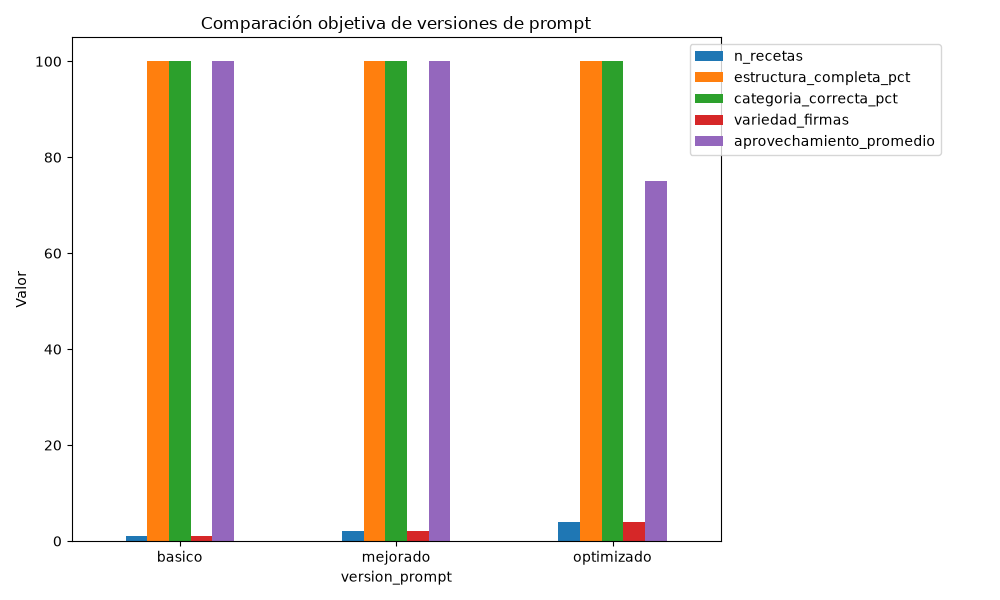

In [10]:
# Mostrar gráfico de comparación
from IPython.display import Image, display
display(Image(filename=grafico_path))


## 17. Evaluación

Evaluación de dos capas:
1. **Métricas objetivas** (calculadas en código): estructura, fidelidad de ingredientes, categoría correcta, variedad, aprovechamiento.
2. **LLM-as-judge** (método subjetivo auxiliar): rúbrica anclada 1-5 sobre claridad, relevancia, cumplimiento, uso de ingredientes, estructura, variedad y utilidad.

> **Nota metodológica:** el juez es un evaluador auxiliar; las conclusiones principales se basan en las métricas objetivas. Con n=3 escenarios, las conclusiones son indicativas, no estadísticamente significativas.


In [11]:
# 17. Evaluación con métricas objetivas y juez
from recetaexpress.evaluacion import metricas_objetivas, evaluar_con_juez

# Métricas del prompt optimizado
metricas = metricas_objetivas(resultado_optimizado["respuesta_validada"], ingredientes_pocos, catalogo, BASICOS_DESPENSA)
print("Métricas objetivas del prompt optimizado:")
for k, v in metricas.items():
    print(f"  {k}: {v}")

# Evaluación con juez (solo si hay API key, para no gastar cuota del fallback)
if os.getenv("GEMINI_API_KEY"):
    eval_juez, meta_juez = evaluar_con_juez(
        lambda p, **kw: generate_text(p, provider="gemini", **kw),
        json.dumps(resultado_optimizado["respuesta_validada"], ensure_ascii=False, indent=2),
    )
    print("\nEvaluación del juez:")
    for criterio, vals in eval_juez["criterios"].items():
        print(f"  {criterio}: {vals['nota']}/5 - {vals['justificacion']}")
else:
    print("\n[Omitido] No hay GEMINI_API_KEY; el juez requiere el modelo Gemini.")


Métricas objetivas del prompt optimizado:
  n_recetas: 4
  estructura_completa_pct: 100
  ingredientes_inventados: 0
  categoria_correcta_pct: 100.0
  variedad_firmas: 4
  aprovechamiento_promedio: 75.0



Evaluación del juez:
  claridad: 5/5 - Las descripciones de cada receta son claras y fáciles de entender, por ejemplo: 'Un plato completo y reconfortante donde el pollo se dora junto con la cebolla'.
  relevancia: 5/5 - Las recetas se basan estrictamente en los ingredientes básicos proporcionados como pollo, arroz, cebolla, aceite, agua, sal y pimienta.
  cumplimiento_instrucciones: 5/5 - Se respetan todas las restricciones: no se inventan ingredientes ('ingredientes_inventados_detectados': []), se indican faltantes vacíos y se clasifica correctamente.
  uso_ingredientes: 5/5 - Utiliza exclusivamente los ingredientes disponibles en el sistema sin añadir elementos externos no autorizados.
  estructura: 5/5 - El formato JSON es completamente válido, estructurado y sigue la jerarquía esperada para este tipo de respuestas.
  variedad: 4/5 - A pesar de tener pocos ingredientes base, ofrece buena variedad con platos como salteado, arroz estofado, plancha y caldoso.
  utilidad: 5/5 - Es muy 

## 18. Texto → Imagen

Seleccionamos una receta representativa —**Arroz con pollo clásico en sartén**— y usamos el modelo texto→texto como intermediario para generar un prompt visual en inglés. Luego descargamos la imagen desde Pollinations (herramienta gratuita).


Receta elegida: Arroz con pollo clásico en sartén
Ingredientes: ['pollo', 'arroz', 'cebolla', 'aceite', 'sal']



Prompt visual (ES): Fotografía culinaria profesional de arroz con pollo clásico en sartén, con jugosas piezas de pollo doradas intercaladas entre granos de arroz sazonados perfectamente cocidos y cebollas salteadas translúcidas. Servido en un bol de cerámica rústica sobre una mesa de madera oscura. Suave luz natural de ventana que resalta las texturas y el vapor que asciende suavemente del plato. Composición en ángulo de 45 grados, poca profundidad de campo, ambiente cálido de cocina casera. Sin texto, sin logotipos, sin personas, sin elementos no relacionados.

Prompt visual (EN): Professional food photography of classic skillet chicken and rice, featuring juicy golden-brown chicken pieces nestled among perfectly cooked grains of seasoned rice, garnished with translucent sautéed onions. Served in a rustic ceramic bowl on a dark wooden table. Soft natural window light highlighting the textures and steam rising gently from the dish. 45-degree angle composition, shallow depth of field, 


Imagen guardada en: C:\Users\USUARIO\Desktop\IA Generacion Prompts\images\arroz_con_pollo_clasico_en_sarten.jpg


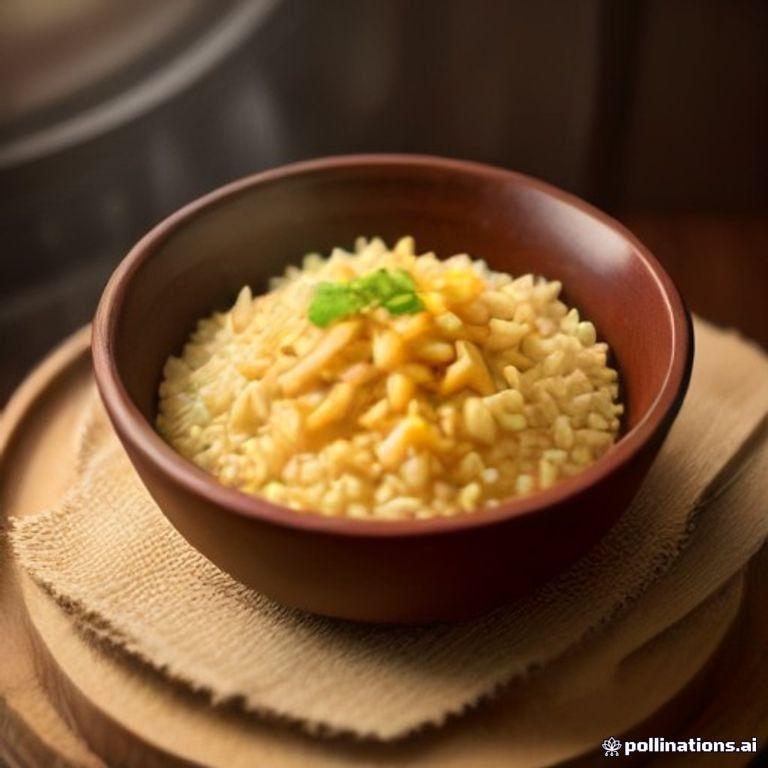

In [12]:
# 18. Texto → Imagen
from recetaexpress.imagenes import generar_prompt_imagen, generar_imagen
from IPython.display import Image as IPImage, display

# Receta fija del caso de estudio para que los nombres de archivo sean deterministas
receta_elegida = {
    "nombre": "Arroz con pollo clásico en sartén",
    "descripcion": "Un clásico reconfortante de arroz y pollo dorado en sartén, con cebolla caramelizada y un toque de pimienta.",
    "ingredientes_utilizados": ["pollo", "arroz", "cebolla", "aceite", "sal"],
    "tiempo": "35 minutos",
    "dificultad": "Media",
}

print(f"Receta elegida: {receta_elegida['nombre']}")
print(f"Ingredientes: {receta_elegida['ingredientes_utilizados']}")

# Paso 1: el modelo de texto actúa como intermediario y escribe el prompt visual
prompts_visuales, meta_visual = generar_prompt_imagen(cliente_llm, receta_elegida)
print(f"\nPrompt visual (ES): {prompts_visuales['prompt_es']}")
print(f"\nPrompt visual (EN): {prompts_visuales['prompt_en']}")

# Paso 2: ese prompt se envía al generador de imágenes gratuito
ruta_imagen = generar_imagen(prompts_visuales["prompt_en"], receta_elegida["nombre"], seed=42)
print(f"\nImagen guardada en: {ruta_imagen}")

display(IPImage(filename=ruta_imagen))


## 19. Resultados

Resumen de los tres escenarios experimentales y del descubrimiento progresivo.


In [13]:
# 19. Resultados - Escenarios
from recetaexpress.recetas import descubrimiento_progresivo

escenarios_a_correr = {
    "pocos": escenarios["pocos"],
    "intermedio": escenarios["intermedio"],
}

resultados_escenarios = {}
for nombre, ingredientes in escenarios_a_correr.items():
    res = generar_recomendaciones(
        cliente_llm,
        "optimizado",
        ingredientes,
        catalogo,
        BASICOS_DESPENSA,
    )
    resultados_escenarios[nombre] = res
    print(f"\nEscenario '{nombre}' ({ingredientes}):")
    print(f"  Disponibles: {len(res['respuesta_validada']['recetas_disponibles'])}")
    print(f"  1 faltante: {len(res['respuesta_validada']['recetas_un_ingrediente'])}")
    print(f"  2 faltantes: {len(res['respuesta_validada']['recetas_dos_ingredientes'])}")
    print(f"  Errores: {len(res['errores'])}")



Escenario 'pocos' (['pollo', 'arroz', 'cebolla']):
  Disponibles: 4
  1 faltante: 0
  2 faltantes: 0
  Errores: 0



Escenario 'intermedio' (['pollo', 'arroz', 'cebolla', 'tomate', 'huevo', 'papa', 'queso']):
  Disponibles: 5
  1 faltante: 0
  2 faltantes: 0
  Errores: 0


In [14]:
# Descubrimiento progresivo
secuencia = [
    ("Paso 1: base", escenarios["progresivo"]["paso_1"]),
    ("Paso 2: +huevo", escenarios["progresivo"]["paso_2"]),
    ("Paso 3: +tomate", escenarios["progresivo"]["paso_3"]),
]

progresivo = descubrimiento_progresivo(
    cliente_llm,
    "optimizado",
    secuencia,
    catalogo,
    BASICOS_DESPENSA,
)

for paso in progresivo:
    print(f"\n{paso['paso']}")
    print(f"  Ingredientes: {paso['ingredientes']}")
    print(f"  Total de recetas: {paso['total_recetas']}")
    print(f"  Nuevas recetas: {paso['novedades']}")



Paso 1: base
  Ingredientes: ['pollo', 'arroz', 'cebolla']
  Total de recetas: 4
  Nuevas recetas: ['Arroz caldoso con pollo', 'Arroz con cebolla estofada', 'Pollo a la plancha con cebolla caramelizada', 'Pollo salteado con cebolla y arroz']

Paso 2: +huevo
  Ingredientes: ['pollo', 'arroz', 'cebolla', 'huevo']
  Total de recetas: 5
  Nuevas recetas: ['Arroz Frito con Huevo y Cebolla', 'Arroz con Pollo Básico', 'Huevo Duro con Pollo Desmenuzado', 'Pollo Salteado con Cebolla', 'Sopa de Pollo con Arroz']

Paso 3: +tomate
  Ingredientes: ['pollo', 'arroz', 'cebolla', 'huevo', 'tomate']
  Total de recetas: 3
  Nuevas recetas: ['Arroz con Pollo Casero y Tomate', 'Pollo encebollado con tomate', 'Tortilla de tomate y cebolla']


## 20. Galería de recetas

El mismo pipeline se aplica a otros tres platos del catálogo para demostrar que no depende de un único ejemplo.



Tortilla de papas
  Prompt EN: Professional food photography of a traditional Spanish potato tortilla on a rustic ceramic plate, perfectly go...


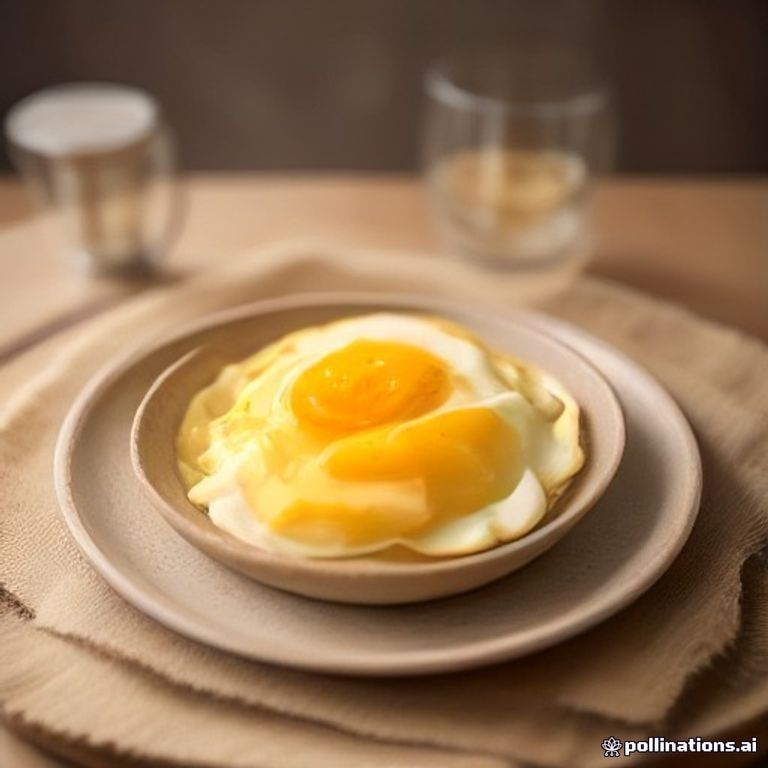


Sopa de verduras
  Prompt EN: Professional food photography of a hearty homemade vegetable soup in a rustic ceramic bowl. Visible chunky ing...


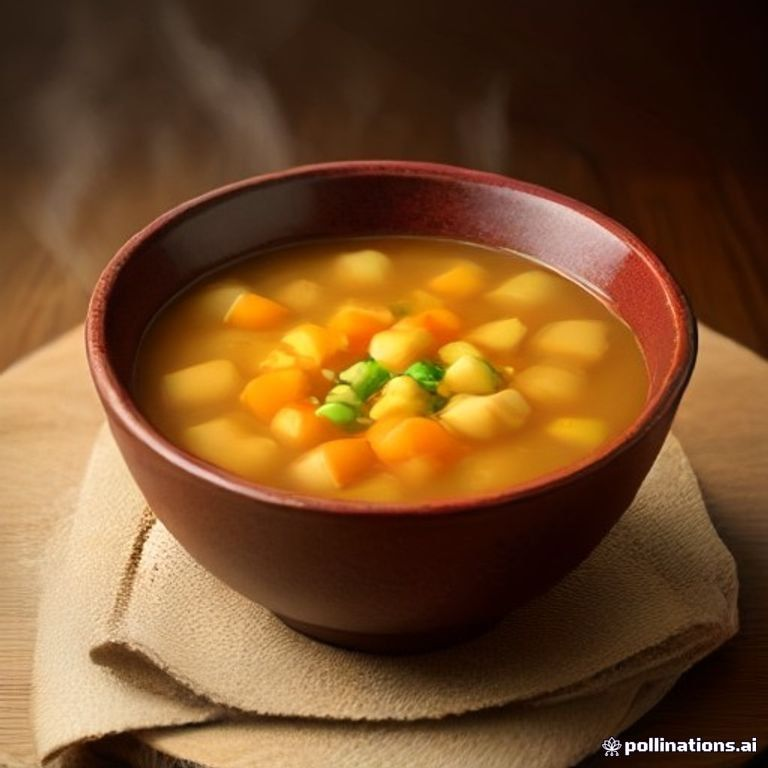


Ensalada mixta
  Prompt EN: Professional food photography of a vibrant mixed salad in a rustic ceramic bowl. Fresh juicy tomato wedges, th...


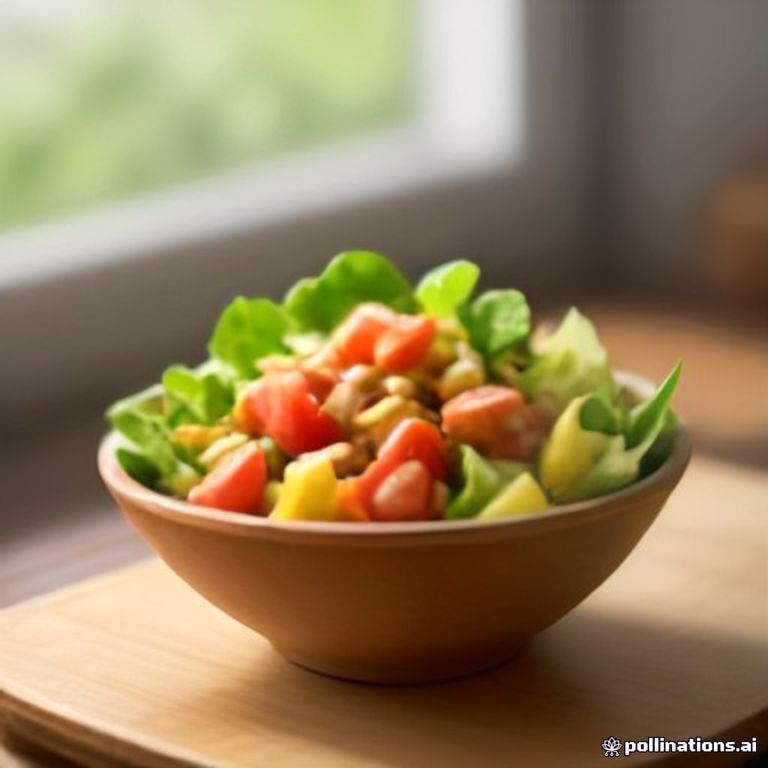

In [15]:
# 20. Galería de recetas
from pathlib import Path
import shutil
from recetaexpress.utils import safe_filename

# Platos adicionales del catálogo (sin repetir el caso de estudio de la sección 18)
recetas_galeria = {
    "Tortilla de papas": ["papa", "huevo", "aceite", "sal"],
    "Sopa de verduras": ["papa", "zanahoria", "cebolla", "aceite", "agua", "sal"],
    "Ensalada mixta": ["tomate", "cebolla", "limón", "aceite", "sal"],
}

Path("images/galeria").mkdir(parents=True, exist_ok=True)
for nombre, ingredientes in recetas_galeria.items():
    receta = {"nombre": nombre, "ingredientes_utilizados": ingredientes}
    prompts_visuales, _ = generar_prompt_imagen(cliente_llm, receta)
    ruta = generar_imagen(prompts_visuales["prompt_en"], nombre, seed=42)

    # La descarga va a images/; la movemos a la carpeta de la galería
    destino = Path("images/galeria") / f"{safe_filename(nombre)}{Path(ruta).suffix}"
    shutil.move(ruta, destino)

    print(f"\n{nombre}")
    print(f"  Prompt EN: {prompts_visuales['prompt_en'][:110]}...")
    display(IPImage(filename=str(destino), width=320))


## 21. Limitaciones del sistema

- El conocimiento culinario del modelo tiene fecha de corte; puede desconocer recetas regionales.
- La validación depende del catálogo y alias definidos; ingredientes fuera del catálogo se tratan como no disponibles.
- El generador de imágenes gratuito (Pollinations) no garantiza fidelidad perfecta a los ingredientes, y su endpoint ignora el parámetro `model`: se verificó que `flux`, `gptimage`, `turbo` y `sana` devuelven un archivo byte a byte idéntico, por lo que no se puede elegir entre modelos.
- Los modelos de imagen nativos de Gemini (`Nano Banana`) no están incluidos en el free tier; requieren facturación.
- Con n=3 escenarios, las conclusiones sobre la superioridad del prompt optimizado son indicativas, no estadísticamente significativas.
- La interfaz con `ipywidgets` requiere ejecutar la notebook en un entorno Jupyter interactivo.
- El sistema no considera restricciones dietéticas, alergias o preferencias personales.


## 22. Conclusiones

Se desarrolló RecetaExpress, una POC que demuestra cómo el *Prompt Engineering* y una capa de validación determinística pueden transformar una consulta simple en una respuesta estructurada y confiable.

Los objetivos se cumplieron:
- Se diseñaron y compararon tres versiones de prompt.
- Se validó la respuesta del modelo para evitar alucinaciones y contradicciones.
- Se implementó el descubrimiento progresivo de recetas.
- Se generó una imagen representativa con una herramienta gratuita.
- Se evaluaron los prompts con métricas objetivas y un juez auxiliar.

La evolución fue clara: el prompt básico produjo respuestas poco controladas; el mejorado añadió estructura; el optimizado, combinado con la validación, generó recetas coherentes, clasificadas correctamente y sin ingredientes inventados. El proyecto es viable técnicamente, económico y escalable a futuras mejoras como restricciones dietéticas, alergias o integración con listas de compras.


## 23. Interfaz interactiva con ipywidgets

Como extensión, agregamos una interfaz nativa de Jupyter: el usuario selecciona ingredientes, presiona un botón y obtiene recomendaciones; luego puede elegir una receta y generar su imagen o audio.

> **Nota:** los widgets requieren ejecutar la notebook en Jupyter Notebook/JupyterLab. En la vista estática de GitHub se ve la interfaz con la salida de ejemplo precargada.


In [16]:
# 23. Interfaz interactiva con ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output, Audio as IPAudio, Image as IPImage

# Widgets de entrada
ingredientes_select = widgets.SelectMultiple(
    options=sorted([item['canonical'] for item in catalogo]),
    value=tuple(escenarios['pocos']),
    description='Ingredientes',
    layout=widgets.Layout(width='320px', height='180px')
)
btn_recomendar = widgets.Button(description="Generar recomendaciones", button_style="primary")
receta_dropdown = widgets.Dropdown(description="Receta", options=[], layout=widgets.Layout(width='420px'))
btn_imagen = widgets.Button(description="Generar imagen")
btn_audio = widgets.Button(description="Generar audio")
output_ui = widgets.Output()

def on_recomendar(b):
    with output_ui:
        clear_output(wait=True)
        disponibles = list(ingredientes_select.value)
        if not disponibles:
            print("Selecciona al menos un ingrediente.")
            return
        res = generar_recomendaciones(
            cliente_llm, "optimizado", disponibles, catalogo, BASICOS_DESPENSA
        )
        print(f"Ingredientes: {disponibles}")
        print(f"Disponibles: {len(res['respuesta_validada']['recetas_disponibles'])}")
        print(f"1 faltante: {len(res['respuesta_validada']['recetas_un_ingrediente'])}")
        print(f"2 faltantes: {len(res['respuesta_validada']['recetas_dos_ingredientes'])}")
        opciones = []
        for cat in ["recetas_disponibles", "recetas_un_ingrediente", "recetas_dos_ingredientes"]:
            for r in res["respuesta_validada"][cat]:
                opciones.append((f"{r['nombre']} ({cat})", r))
        receta_dropdown.options = opciones
        if opciones:
            receta_dropdown.value = opciones[0][1]
            print(f"\nPrimera receta: {opciones[0][1]['nombre']}")
            print(f"  Usados: {opciones[0][1]['ingredientes_utilizados']}")
            print(f"  Faltantes: {opciones[0][1]['ingredientes_faltantes']}")

def on_imagen(b):
    with output_ui:
        clear_output(wait=True)
        receta = receta_dropdown.value
        if not receta:
            print("Primero generá recomendaciones y elegí una receta.")
            return
        prompts_visuales, _ = generar_prompt_imagen(cliente_llm, receta)
        ruta = generar_imagen(prompts_visuales["prompt_en"], receta["nombre"], seed=42)
        print(f"Receta: {receta['nombre']}")
        print(f"Imagen: {ruta}")
        display(IPImage(filename=ruta, width=400))

def on_audio(b):
    with output_ui:
        clear_output(wait=True)
        receta = receta_dropdown.value
        if not receta:
            print("Primero generá recomendaciones y elegí una receta.")
            return
        texto = (
            f"Hoy preparamos {receta['nombre']}. {receta['descripcion']} "
            f"Necesitarás {', '.join(receta['ingredientes_utilizados'])}. "
            f"Tiempo aproximado: {receta['tiempo']}. Dificultad: {receta['dificultad']}."
        )
        path = generar_audio(texto, receta['nombre'])
        print(f"Audio generado: {path}")
        display(IPAudio(filename=path))

btn_recomendar.on_click(on_recomendar)
btn_imagen.on_click(on_imagen)
btn_audio.on_click(on_audio)

ui = widgets.VBox([
    widgets.HBox([
        ingredientes_select,
        widgets.VBox([btn_recomendar, receta_dropdown, btn_imagen, btn_audio])
    ]),
    output_ui
])
display(ui)

# Precargar demo con los ingredientes por defecto
on_recomendar(None)


## Contenido adicional: Texto → Audio

Como extensión, generamos una narración de la receta elegida usando `edge-tts`, una herramienta gratuita y sin API key.


In [17]:
# Texto → Audio
import nest_asyncio2 as nest_asyncio
nest_asyncio.apply()

from recetaexpress.audio import generar_audio

texto_narracion = (
    f"Hoy preparamos {receta_elegida['nombre']}. "
    f"{receta_elegida['descripcion']} "
    f"Necesitarás {', '.join(receta_elegida['ingredientes_utilizados'])}. "
    f"Tiempo aproximado: {receta_elegida['tiempo']}. "
    f"Dificultad: {receta_elegida['dificultad']}."
)

audio_path = generar_audio(texto_narracion, receta_elegida['nombre'])
print(f"Audio guardado en: {audio_path}")

from IPython.display import Audio as IPAudio, display as ipy_display
ipy_display(IPAudio(filename=audio_path))


Audio guardado en: C:\Users\USUARIO\Desktop\IA Generacion Prompts\audio\arroz_con_pollo_clasico_en_sarten.mp3


## Verificación de seguridad

Revisamos que no haya claves de API u otros secretos en los archivos del repositorio.


In [18]:
# Verificación de seguridad
import re
from pathlib import Path

sospechosos = []
patrones = [
    re.compile(r"AIza[\w-]{35}", re.IGNORECASE),  # Google API key
    re.compile(r"sk-[a-zA-Z0-9]{20,}", re.IGNORECASE),  # OpenAI-style key
    re.compile(r"password\s*=\s*['\"][^'\"]+['\"]", re.IGNORECASE),
]

EXCLUIDOS = {".git", ".venv", "__pycache__", "node_modules"}
EXTENSIONES = {".py", ".md", ".json", ".txt", ".ipynb", ".env", ".example"}

revisados = 0
for p in Path(".").rglob("*"):
    if not p.is_file() or p.name == ".env":
        continue
    if EXCLUIDOS & set(p.parts) or p.suffix.lower() not in EXTENSIONES:
        continue
    revisados += 1
    texto = p.read_text(encoding="utf-8", errors="ignore")
    for pat in patrones:
        if pat.search(texto):
            sospechosos.append((str(p), pat.pattern))
            break

if sospechosos:
    print("⚠️ Posibles secretos detectados:")
    for archivo, patron in sospechosos:
        print(f"  {archivo} coincide con {patron}")
else:
    print(f"✅ No se detectaron secretos en {revisados} archivos de texto (excluyendo .env, que está en .gitignore).")


✅ No se detectaron secretos en 39 archivos de texto (excluyendo .env, que está en .gitignore).
